# Adaptive Thresholding using Otsu's Method

Global Otsu picks one threshold for the whole image, which breaks down under uneven illumination. 
Adaptive (local) Otsu fixes this by computing Otsu's threshold **per block** and building a smooth threshold surface $T(x, y)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from skimage import data

## 1. Load a Sample Image

`skimage.data.page()` is a scanned page with uneven lighting across it — a classic case where global thresholding fails.

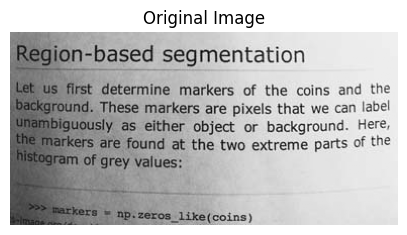

In [3]:
image = data.page()  # grayscale uint8 image with uneven illumination

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

## 2. Global Otsu Threshold (from scratch)

$$T^* = \arg\max_T \; \omega_0(T)\,\omega_1(T)\,[\mu_0(T) - \mu_1(T)]^2$$

Implemented with running sums over the histogram so it's a single pass, no need to recompute means from scratch at every $T$.

In [4]:
def otsu_threshold(img):
    """Compute Otsu's global threshold for a grayscale image (0-255)."""
    hist, _ = np.histogram(img.ravel(), bins=256, range=(0, 256))
    hist = hist.astype(float)
    total = img.size

    sum_all = np.dot(np.arange(256), hist)
    sum_bg, weight_bg = 0.0, 0.0
    max_var, threshold = 0.0, 0

    for t in range(256):
        weight_bg += hist[t]
        if weight_bg == 0:
            continue
        weight_fg = total - weight_bg
        if weight_fg == 0:
            break

        sum_bg += t * hist[t]
        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_all - sum_bg) / weight_fg

        var_between = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2
        if var_between > max_var:
            max_var, threshold = var_between, t

    return threshold

Global Otsu threshold: 157


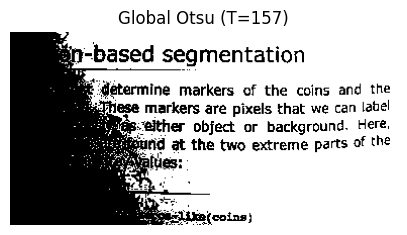

In [5]:
global_t = otsu_threshold(image)
global_seg = (image > global_t).astype(np.uint8) * 255

print(f'Global Otsu threshold: {global_t}')

plt.figure(figsize=(5, 5))
plt.imshow(global_seg, cmap='gray')
plt.title(f'Global Otsu (T={global_t})')
plt.axis('off')
plt.show()

## 3. Adaptive Otsu Thresholding

**Algorithm:**
1. Split the image into `block_size x block_size` blocks
2. Run `otsu_threshold` on each block (fall back to the global threshold if a block is near-flat/unimodal)
3. Interpolate the block-level thresholds up to a full-resolution threshold surface
4. Threshold each pixel against its local value in that surface

In [6]:
def adaptive_otsu(img, block_size=25):
    """Locally adaptive Otsu thresholding via blockwise Otsu + interpolation."""
    h, w = img.shape

    # Pad so the image divides evenly into blocks
    pad_h = (block_size - h % block_size) % block_size
    pad_w = (block_size - w % block_size) % block_size
    padded = np.pad(img, ((0, pad_h), (0, pad_w)), mode='reflect')
    ph, pw = padded.shape

    n_rows, n_cols = ph // block_size, pw // block_size
    block_thresholds = np.zeros((n_rows, n_cols))
    global_fallback = otsu_threshold(img)

    for i in range(n_rows):
        for j in range(n_cols):
            block = padded[i*block_size:(i+1)*block_size,
                           j*block_size:(j+1)*block_size]
            if block.max() == block.min():
                block_thresholds[i, j] = global_fallback  # flat block, no separation
            else:
                block_thresholds[i, j] = otsu_threshold(block)

    # Upsample block-level thresholds into a smooth per-pixel threshold surface
    threshold_map = zoom(block_thresholds, (ph / n_rows, pw / n_cols), order=1)
    threshold_map = threshold_map[:h, :w]  # crop back to original size

    segmented = (img > threshold_map).astype(np.uint8) * 255
    return segmented, threshold_map

In [7]:
adaptive_seg, threshold_map = adaptive_otsu(image, block_size=25)

## 4. Compare Results

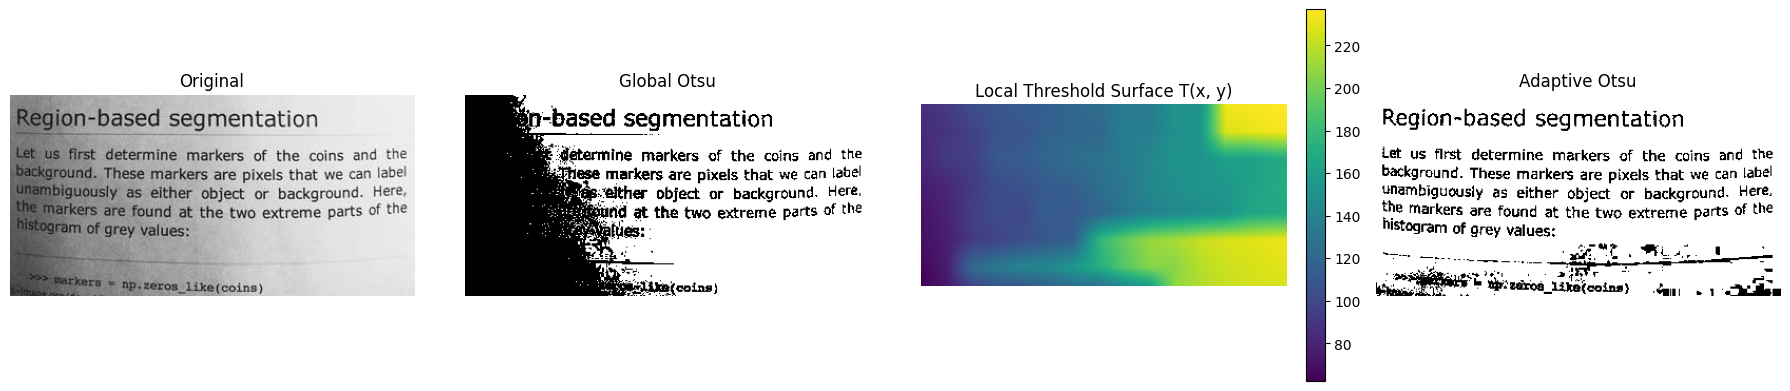

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(global_seg, cmap='gray')
axes[1].set_title('Global Otsu')

im = axes[2].imshow(threshold_map, cmap='viridis')
axes[2].set_title('Local Threshold Surface T(x, y)')
fig.colorbar(im, ax=axes[2], fraction=0.046)

axes[3].imshow(adaptive_seg, cmap='gray')
axes[3].set_title('Adaptive Otsu')

for ax in axes[:2].tolist() + [axes[3]]:
    ax.axis('off')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Notes**
- `block_size` controls the granularity of local adaptation — smaller blocks adapt faster to local lighting changes but are noisier and more prone to unreliable histograms; larger blocks are smoother but adapt less.
- Try `block_size` values like 15, 25, 50 and compare the threshold surface and segmentation quality.
- For a sanity check against a library implementation, compare with `skimage.filters.threshold_otsu(image)` (global) and `skimage.filters.threshold_local` (adaptive, though it uses mean/Gaussian weighting rather than Otsu).